In [ ]:
# !pip install bitsandbytes transformers accelerate captum

In [ ]:
from google.colab import drive, files
drive.mount('/content/drive')

In [3]:
import os
import sys

path = os.getcwd()
while True:
    if 'utils.py' in os.listdir(path):
        if path not in sys.path:
            sys.path.append(path)
        break
    new_path = os.path.dirname(path)
    if new_path == path:
        upload_utils = files.upload()
        break
    path = new_path

import utils
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import torch

/opt/anaconda3/envs/nlp/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Global Parameters of Notebook
global_params = {'dataset_type': 'scitail',
                'quantization': '4bit',
                'training_mode': 'zero shot MP',
                'model_id': 'google/gemma-2-9b-it'}

# Create checkpoint
checkpoint_path = utils.create_checkpoint_path(params=global_params)

Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/Scitail_Notebooks/Scitail_gemma_2_9b_it/Zero-Shot/checkpoint_scitail_gemma_2_9b_it_4bit_zero_shot_MP.pt


In [ ]:
utils.hf_login("HF_TOKEN")

In [ ]:
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4"
)

In [5]:
tokenizer = AutoTokenizer.from_pretrained(global_params['model_id'])


In [ ]:
tokenizer = AutoTokenizer.from_pretrained(global_params['model_id'])
model = AutoModelForCausalLM.from_pretrained(
    global_params['model_id'],
    device_map="auto",
    quantization_config=quantization_config,
    attn_implementation="eager"
    )

# Add padding token to the tokenizer
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"

# Change the model to evaluation mode
model.eval()

tokenizer_config.json:   0%|          | 0.00/47.0k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/4.24M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/857 [00:00<?, ?B/s]

...

model-00002-of-00004.safetensors:   0%|          | 0.00/4.95G [00:00<?, ?B/s]

model-00004-of-00004.safetensors:   0%|          | 0.00/3.67G [00:00<?, ?B/s]

model-00003-of-00004.safetensors:   0%|          | 0.00/4.96G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

In [6]:
scitail_test = pd.read_csv('/Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Datasets/Scitail/scitail_test.csv')

"""Zero-shot MP Template: For the premise:

“[premise]” and hypothesis: “[hypothesis]”, determine if the premise entails the hypothesis.

If the premise contains sufficient evidence that the hypothesis is true, the status is entailment.
If it does not, the status is neutral. 

As you perform this task, follow these steps:

1. Clarify your understanding of the hypothesis and the premise.

2. Make a preliminary identification of
whether the premise contains the
answer to the question.

3. Critically assess your preliminary analy-
sis. If you feel unsure about your initial
entailment classification, try to reassess
it.

4. Confirm your final answer and explain
the reasoning behind your choice.

5. Evaluate your confidence (0-100%) in
your analysis and provide an explanation
for this confidence level.

Provide the answer in your final response as
“(entailment / neutral)”."""

'Zero-shot MP Template: For the premise:\n\n“[premise]” and hypothesis: “[hypothesis]”, determine if the premise entails the hypothesis.\n\nIf the premise contains sufficient evidence that the hypothesis is true, the status is entailment.\nIf it does not, the status is neutral. \n\nAs you perform this task, follow these steps:\n\n1. Clarify your understanding of the hypothesis and the premise.\n\n2. Make a preliminary identification of\nwhether the premise contains the\nanswer to the question.\n\n3. Critically assess your preliminary analy-\nsis. If you feel unsure about your initial\nentailment classification, try to reassess\nit.\n\n4. Confirm your final answer and explain\nthe reasoning behind your choice.\n\n5. Evaluate your confidence (0-100%) in\nyour analysis and provide an explanation\nfor this confidence level.\n\nProvide the answer in your final response as\n“(entailment / neutral)”.'

In [ ]:
scitail_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 4 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   premise                     2126 non-null   object
 1   hypothesis                  2126 non-null   object
 2   label                       2126 non-null   object
 3   hypothesis_graph_structure  2126 non-null   object
dtypes: object(4)
memory usage: 66.6+ KB


In [ ]:
scitail_test.head()

,premise,hypothesis,label,hypothesis_graph_structure
0,Based on the list provided of the uses of subs...,"If a substance has a ph value greater than 7,t...",neutral,a substance<>has<>a ph value greater than 7
1,If one or two base pairs are change...,Invertebrates (and higher animals) can also be...,neutral,Invertebrates (and higher animals<>can be plac...
2,"At high temperatures, the solid dye converts i...",Gases and liquids become solids at low tempera...,neutral,Gases and liquids<>become<>solids
3,Chapter 11 Gas and Kinetic Theory .,The behavior of ideal gases is explained by ki...,neutral,The behavior of ideal gases<>is explained<>by ...
4,Both the continental crust and the oceanic cru...,Gabbro is a dark dense rock that can be found ...,neutral,Gabbro<>is<>a dark dense rock that can be foun...


In [ ]:
# Find the max_length for tokenization to avoid wasting computing.
utils.find_max_length(scitail_test, tokenizer=tokenizer, dataset_type=global_params['dataset_type'])

In [27]:
from importlib import reload
reload(utils)
# Define dataset and create a dataloader.
dataset_test = utils.MyDataset_MP(dataframe=scitail_test,
                               tokenizer=tokenizer,
                               dataset_type=global_params['dataset_type'],
                               prompt_max_length=117,
                               label_max_length=3)

batch_size = 16 # Change batch size according to GPU
dataloader = DataLoader(dataset_test, batch_size=batch_size, shuffle=False)

In [38]:
scitail_test.iloc[8]

premise                       A polyploid is simply an organism that contain...
hypothesis                    A(n) polyploid is an individual with more than...
label                                                                   entails
hypothesis_graph_structure    A(n) polyploid<>is<>an individual with more th...
Name: 8, dtype: object

In [30]:
print(dataset_test[7]['prompt'])

For the premise: Corolla Collective term for all the petals of a flower, these petals may be separate or fused together.
and hypothesis: All of the petals together are called a corolla., determine if the premise entails the hypothesis.
If the premise contains sufficient evidence that the hypothesis is true, the status is entailment.
If it does not, the status is neutral.
As you perform this task, follow these steps:
1. Clarify your understanding of the hypothesis and the premise.
2. Make a preliminary identification of whether the premise contains the answer to the question.
3. Critically assess your preliminary analysis. If you feel unsure about your initial entailment classification, try to reassess it.
4. Confirm your final answer and explain the reasoning behind your choice.
5. Evaluate your confidence (0-100%) in your analysis and provide an explanation for this confidence level.
Provide the answer in your final response as entailment or neutral.


In [ ]:
# Test
predictions, gold_labels, batch_probs = utils.test_run(model=model,
                                          dataloader=dataloader,
                                          tokenizer=tokenizer,
                                          dataset_type=global_params['dataset_type'])

for i, pair in enumerate(zip(predictions, gold_labels)):
    print(pair, batch_probs[i])

neutral
neutral
neutral
entailment


In [ ]:
from tqdm import tqdm

# Load checkpoint if it exists
predicted_labels, gold_labels, start_batch = utils.load_checkpoint(checkpoint_path=checkpoint_path)
labels = utils.get_labels('scitail')

# Loop over the batches
with torch.no_grad():
    for i, batch in enumerate(tqdm(dataloader, desc="Evaluating", unit="batch")):

        # Continue from last checkpoint
        if i < start_batch:
            continue

        input_ids_batch = batch["input_ids"].to(model.device) # Move to GPU
        attention_mask_batch = batch["attention_mask"].to(model.device) # Move to GPU
        gold_labels_batch = batch["labels"] # Keep to CPU

        batch_probs = utils.get_model_probs(batch_input_ids=input_ids_batch,
                                      batch_attention_mask=attention_mask_batch,
                                      dataset_type=global_params['dataset_type'],
                                      model=model,
                                      tokenizer=tokenizer)

        batch_pred_indices = torch.argmax(batch_probs, dim=1)
        batch_pred_labels = [labels[i] for i in batch_pred_indices]

        predicted_labels.extend(batch_pred_labels)
        gold_labels.extend(gold_labels_batch)

        # Save checkpoint
        if i % 50 == 0 or i == len(dataloader) - 1:
            torch.save({"predicted_labels": predicted_labels,
                        "gold_labels": gold_labels,
                        "batch_no": i+1}, checkpoint_path)

            print(f"Checkpoint saved: {i+1}, {checkpoint_path}")

Checkpoint found.
Accuracy: 0.5922.
 F1 Score: 0.5610.
 Matthew's Correlation Coefficient: 0.1262.
 Cohen's Kappa Score: 0.1252.


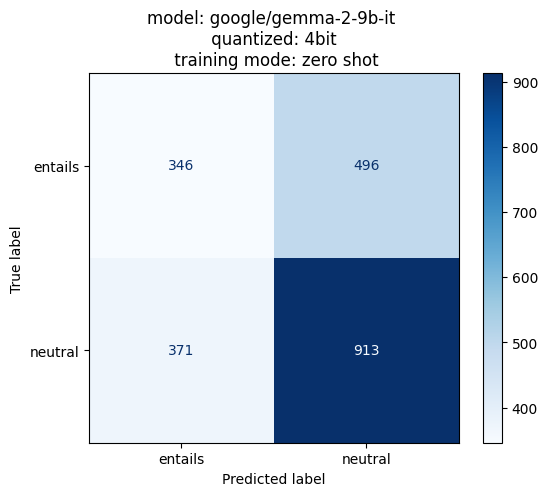

In [ ]:
# Calculate metrics
predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path='/Users/giorgosdikaios/Library/Mobile Documents/com~apple~CloudDocs/Desktop/DAMA_EAP/NLI_Study/Notebooks/Scitail_Notebooks/Scitail_gemma_2_9b_it/Zero-Shot/checkpoint_scitail_gemma_2_9b_it_4bit_add_special_tokens_True_zero_shot.pt')
utils.evaluate_metrics(predicted_labels=predicted_labels, gold_labels=gold_labels, params=global_params)

Checkpoint found.
Accuracy: 0.5922.
 F1 Score: 0.5610.
 Matthew's Correlation Coefficient: 0.1262.
 Cohen's Kappa Score: 0.1252.


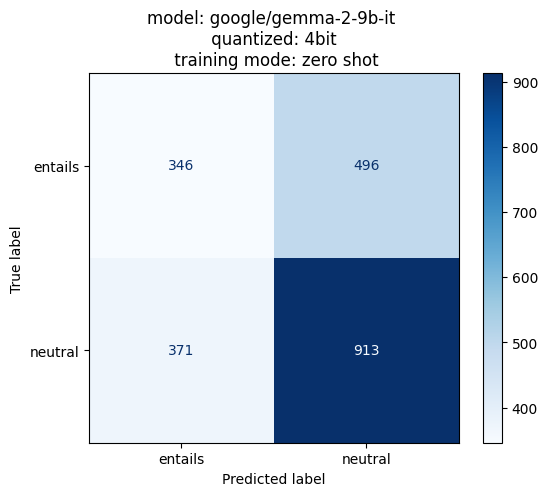

In [ ]:
# Calculate metrics with padding_side="left"
predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)
utils.evaluate_metrics(predicted_labels=predicted_labels, gold_labels=gold_labels, params=global_params)

Checkpoint found.
Accuracy: 0.5997.
 F1 Score: 0.5688.
 Matthew's Correlation Coefficient: 0.1421.
 Cohen's Kappa Score: 0.1410.


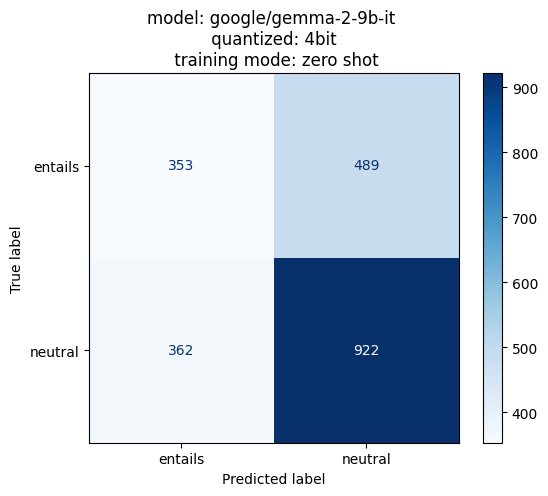

In [ ]:
# Calculate metrics
predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)
utils.evaluate_metrics(predicted_labels=predicted_labels, gold_labels=gold_labels, params=global_params)